<a href="https://colab.research.google.com/github/AbdelRayan/AutomaticSleepScoring/blob/main/Faranak/Complexity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

## Libraries

In [6]:
# %%capture
# !pip install neurodsp
# !pip install emd
# !pip install tslearn
# !pip install dtaidistance
# !pip install sails
# !pip install specparam
# !pip install EntropyHub
!pip install fooof

C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  res = process_handler(cmd, _system_body)
C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [21]:
import scipy
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from neurodsp.filt import filter_signal, filter_signal_fir, design_fir_filter
import emd
from joblib import Parallel, delayed
import os
import numpy as np
from fooof import FOOOF
import pandas as pd
from sklearn.preprocessing import Normalizer
from tqdm import tqdm
import plotly.express as px
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.metrics import dtw
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
import copy
import sails
import requests
from io import BytesIO
from scipy.fftpack import fft
from scipy.signal import welch
from specparam import SpectralModel
from neurodsp.aperiodic import compute_fluctuations
from scipy.stats import zscore
from scipy.signal import savgol_filter
import EntropyHub as EH
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A

##Colors

In [8]:
Red = '#d13838'
Blue = '#127be3'
DarkBlue = '#09217a'
LightBlue = '#9cd4ff'
Yellow = '#eff250'
Orange = '#faac11'
Purple = '#a170fd'

In [9]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores  

In [10]:
def aperiodic_fit(window_data):
    freqs, psd = welch(window_data, fs=fs, nperseg=1024)
    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]
    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='fixed', verbose=False)
    fm.fit(freqs, psd)
    aperiodic = fm.get_params('aperiodic')[1]
    return aperiodic

# Data

In [11]:
subject = "2"
night = "1"
file_type = "converted_extra_adj_intra"
hpc_channel = 'Oz-Cz'
pfc_channel = "C3-Cz"
os.makedirs(os.path.join("C:/EEG_Data_stage","complexity_plots_bi_intra", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","complexity_plots_bi_intra", file_type, subject, f"night{night}")


In [12]:
files, scores_files = fragment_join(subject, night, file_type)
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)
raw_pfc, inds, timeval = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lo

In [13]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

In [14]:
lfp_PFC = np.ravel(pfc_data)  # flatten in case it's 2D
sleep_states = states.flatten() 

In [15]:
for idx in range(len(sleep_states)):
    if sleep_states[idx] == 0:
        print(idx)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

##OS Basic

# 1. RGS14: Results for Windowing (4s Windows)

In [16]:
fs = 250
window_size = 10 * fs
step_size = window_size  # In case we wanted overlap later.

In [17]:
import numpy as np

def global_checks(signal, fs=None):
    print("Length (samples):", len(signal))
    print("dtype:", signal.dtype)
    print("Finite values:", np.sum(np.isfinite(signal)), "/", len(signal))
    print("NaNs:", np.sum(np.isnan(signal)))
    print("Infs:", np.sum(~np.isfinite(signal)) - np.sum(np.isnan(signal)))
    print("Min, Max:", np.min(signal), np.max(signal))
    print("Mean, Std:", np.mean(signal), np.std(signal))
    if fs is not None:
        print("Duration (s):", len(signal)/fs)
    # basic kurtosis / skewness (optional)
    try:
        from scipy.stats import skew, kurtosis
        print("Skew:", skew(signal))
        print("Kurtosis:", kurtosis(signal))
    except Exception:
        pass

# Usage:
global_checks(raw_pfc, fs=fs)

Length (samples): 10796608
dtype: float64
Finite values: 10796608 / 10796608
NaNs: 0
Infs: 0
Min, Max: -8.527725219726562e-05 8.386549377441405e-05
Mean, Std: -1.1429672587074001e-08 6.953179614255728e-06
Duration (s): 43186.432
Skew: 0.06296783933611524
Kurtosis: 6.190694347504355


## Aperiodic Fit

Problematic windows: 0
First 10 problematic windows: []


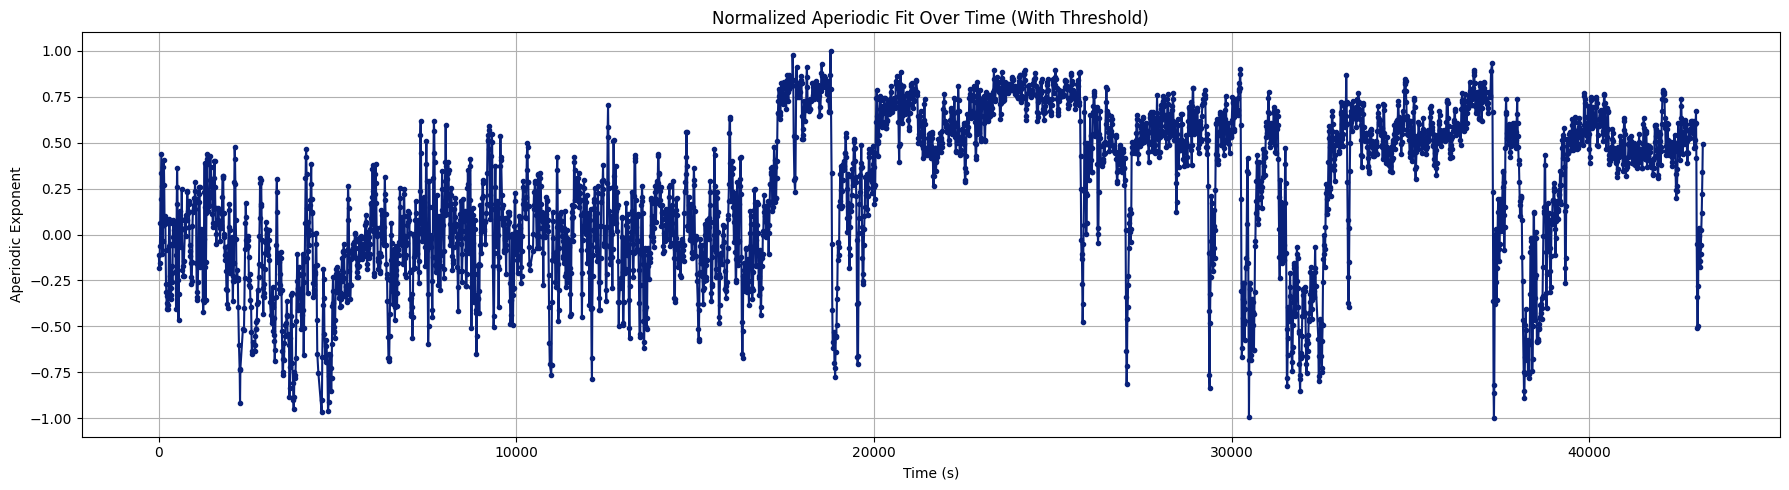

In [18]:
# --- Parameters ---
num_windows = len(lfp_PFC) // window_size
time_stamps = np.arange(num_windows) * 10  # adjust timing scale if needed
window_length = 11  # for Savitzky-Golay
polyorder = 4

# --- Prepare windows ---
window_data = [raw_pfc[i*window_size:(i+1)*window_size] for i in range(num_windows)]

# --- Diagnostic aperiodic fit function ---
def safe_aperiodic_fit(window, idx, aperiodic_fit_fn):
    try:
        # Skip flat/empty windows
        if len(window) == 0 or np.std(window) < 1e-12:
            return np.nan, "flat_or_empty"
        if not np.all(np.isfinite(window)):
            return np.nan, "nonfinite_input"

        # Compute exponent
        exp = aperiodic_fit_fn(window)
        if not np.isfinite(exp):
            return np.nan, "nonfinite_exponent"

        return float(exp), "ok"

    except Exception as e:
        return np.nan, f"exception: {str(e)}"

# --- Compute aperiodic exponents in parallel ---
results = Parallel(n_jobs=-1)(
    delayed(safe_aperiodic_fit)(w, i, aperiodic_fit) for i, w in enumerate(window_data)
)

# --- Extract exponents and statuses ---
aperiodic_exponents, statuses = zip(*results)
aperiodic_exponents = np.array(aperiodic_exponents)

# --- Optional: report problem windows ---
problem_windows = [(i, s) for i, s in enumerate(statuses) if s != "ok"]
print(f"Problematic windows: {len(problem_windows)}")
print("First 10 problematic windows:", problem_windows[:10])

# --- Replace NaNs with median of valid exponents for plotting ---
valid_mask = np.isfinite(aperiodic_exponents)
median_val = np.median(aperiodic_exponents[valid_mask])
aperiodic_exponents[~valid_mask] = median_val

# --- Thresholding to remove extreme outliers ---
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]

# --- Smooth and normalize ---
window_length_sg = window_length if len(filtered_exponents) >= window_length else len(filtered_exponents) | 1
smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length_sg, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - smoothed_exponents.min()) / 
                            (smoothed_exponents.max() - smoothed_exponents.min())) - 1

# --- Plot ---
plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_fit.svg", format='svg')
plt.show()

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 50 Hz                        
                                 Frequency Resolution is 0.24 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -10.1806, 2.2143                                         
                                                                                                  
                                       2 peaks were found:                                        
          

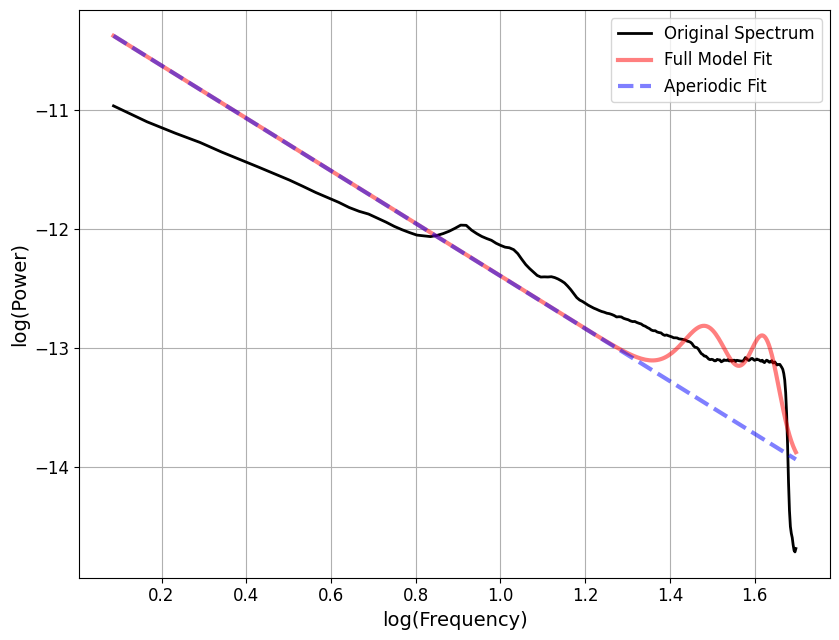

In [23]:
freqs, psd = welch(raw_pfc, fs=250, nperseg=1024)
fm = FOOOF(peak_width_limits=[2, 8], aperiodic_mode='fixed')
fm.report(freqs, psd, [1, 50], plt_log=True)

In [15]:
# print(len(aperiodic_exponents))
# print(len(filtered_exponents))

## DFA

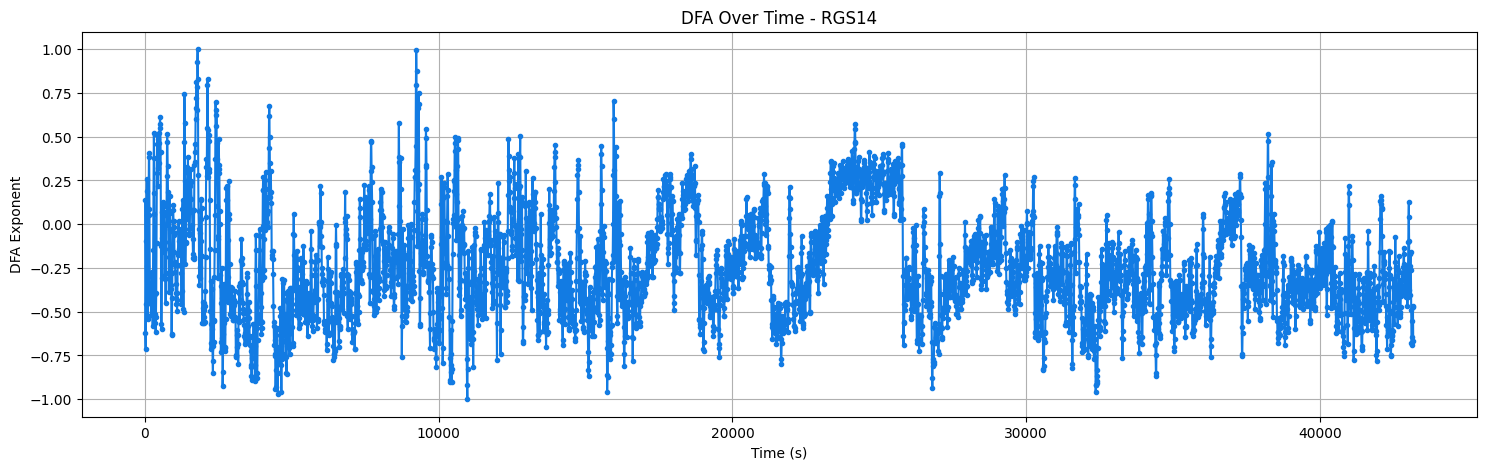

In [16]:
num_windows = (len(lfp_PFC) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - RGS14')
plt.grid()
plt.savefig(f"{output_dir}/DFA_over_time.svg", format='svg')
plt.show()

## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

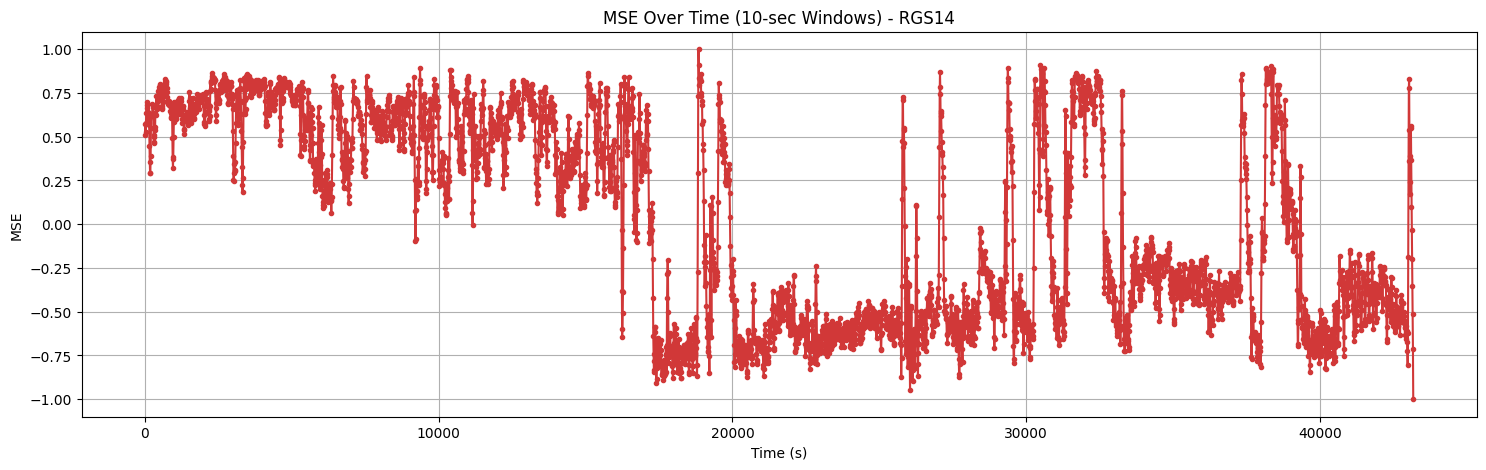

In [17]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_PFC) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time (10-sec Windows) - RGS14')
plt.grid()
plt.savefig(f"{output_dir}/MSE_10s.svg", format='svg')
plt.show()

## Final Plot

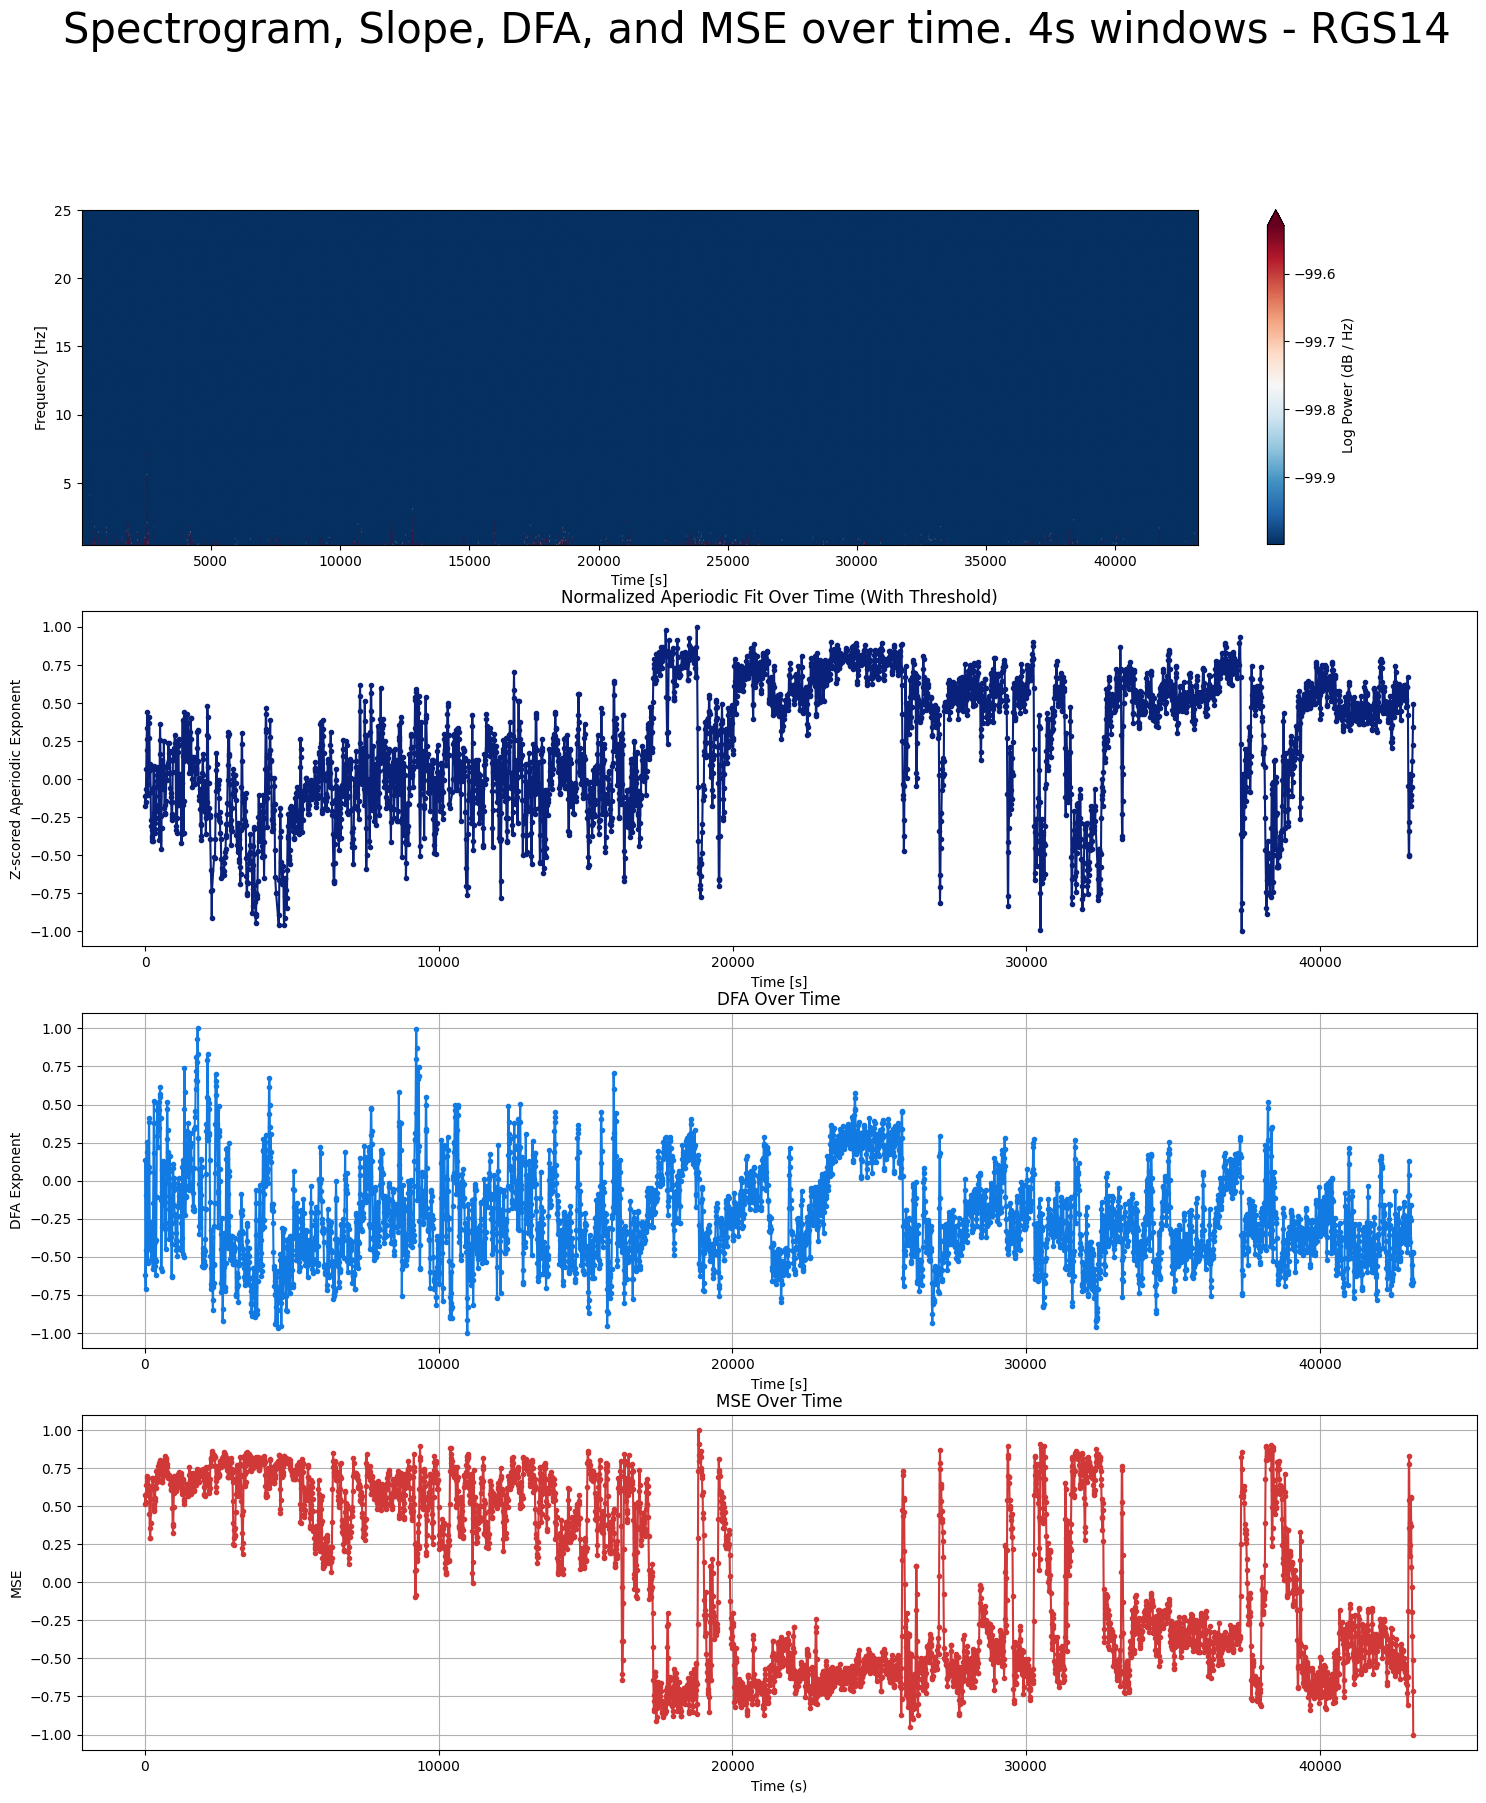

In [18]:
# SPECTROGRAM
nperseg = int(10 * fs)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - RGS14', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_PFC, NFFT=nperseg, Fs=fs, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold)')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time')
axs[3].grid()
plt.savefig(f"{output_dir}/combined.svg", format='svg')
plt.show()

# 2. RGS14: Results for Epochs
-Not Suitable.

In [19]:
def find_all_state_epochs(state_array):
    """
    Returns a list of (start_sample_idx, end_sample_idx, state) tuples.
    Assumes each element in state_array represents 1 second of signal.
    """
    epochs = []
    start_idx = 0

    for i in range(1, len(state_array)):
        if state_array[i] != state_array[i - 1]:
            end_idx = i - 1
            state = state_array[start_idx]
            epochs.append((start_idx, end_idx, state))
            start_idx = i

    # Add last epoch
    epochs.append((start_idx, len(state_array) - 1, state_array[start_idx]))
    return epochs

In [20]:
samples_per_state = fs  # If state_array is per second

aperiodic_exponents = []
state_labels = []
epoch_times = []

state_epochs = find_all_state_epochs(sleep_states)

for idx, (start_sec, end_sec, state) in enumerate(state_epochs):
    # Convert to sample indices
    start_sample = start_sec * samples_per_state
    end_sample = (end_sec + 1) * samples_per_state  # +1 to include the full last second

    epoch_signal = lfp_PFC[start_sample:end_sample]

    # Skip if too short
    if len(epoch_signal) < 2 * fs:
        continue

    # Compute PSD
    freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
    freqs, psd = freqs[freqs <= 100], psd[freqs <= 100]

    # Fit aperiodic component
    try:
        fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
        fm.fit(freqs, psd)
        exponent = fm.get_params('aperiodic')[1]
        aperiodic_exponents.append(exponent)
        state_labels.append(state)
        epoch_times.append(idx)
    except Exception as e:
        print(f"Skipping epoch {idx} due to error: {e}")

C:\Users\timmi\AppData\Local\Temp\ipykernel_1316\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_1316\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 3500, using nperseg = 3500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_1316\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 2750, using nperseg = 2750
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_1316\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 2750, using nperseg = 2750
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_1316\3533767935.py:21: UserWarning: nperseg=40

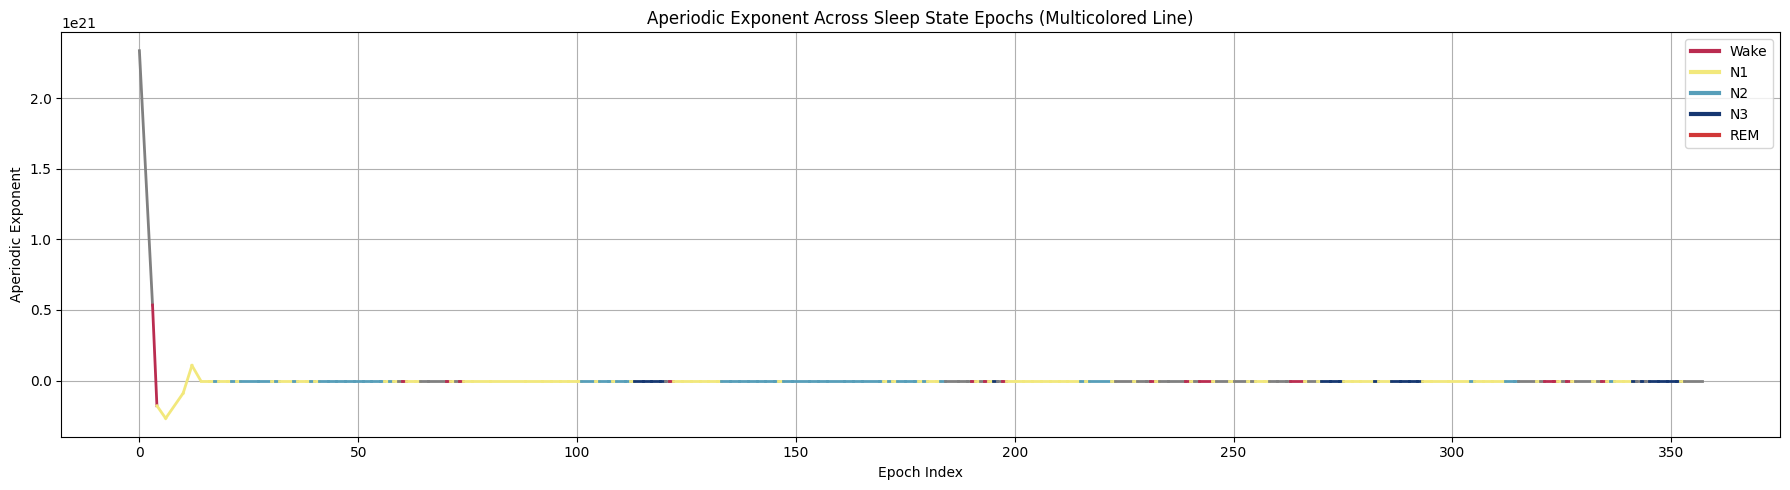

In [21]:
aperiodic_exponents = np.array(aperiodic_exponents)
state_labels = np.array(state_labels)
epoch_times = np.array(epoch_times)

# Remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

#filtered_exponents = aperiodic_exponents[valid]
#filtered_states = state_labels[valid]
#filtered_times = epoch_times[valid]

# Z-score the filtered exponents
#z_exponents = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(aperiodic_exponents) >= 11 else len(aperiodic_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(aperiodic_exponents, window_length=window_length, polyorder=polyorder)

# Color mapping for states
state_map = {1: '#BA2C50', 2: '#F2E87C', 3: '#579EB9', 4: '#163771', 5:Red}
state_names = {1: 'Wake', 2: 'N1', 3: 'N2', 4: 'N3', 5: 'REM'}
plt.figure(figsize=(18, 5))


# Plot each line segment with its state color
for i in range(min(len(epoch_times), len(smoothed_exponents)) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)
# Mean line
#plt.axhline(0, color='red', linestyle='--', label='Mean')

plt.xlabel('Epoch Index')
plt.ylabel('Aperiodic Exponent')
plt.title('Aperiodic Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
#legend_elements.append(plt.Line2D([0], [0], linestyle='--', color='red', label='Mean'))

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_exp_across_sleep_States.svg", format='svg')
plt.show()

In [22]:
# First, find the epochs
epochs = find_all_state_epochs(sleep_states)  # state_array has 1 sample/sec

dfa_exponents = []
epoch_times = []
epoch_labels = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # +1 to include the last second

    segment = lfp_PFC[start_sample:end_sample]

    #if len(segment) < fs * 2:  # skip very short epochs (e.g. <5 sec)
     #   continue

    try:
        _, _, exp_epoch = compute_fluctuations(segment, fs, n_scales=10,
                                               min_scale=0.05, max_scale=4.0)
        dfa_exponents.append(exp_epoch)
        epoch_times.append((start_sample + end_sample) / 2 / fs)
        epoch_labels.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


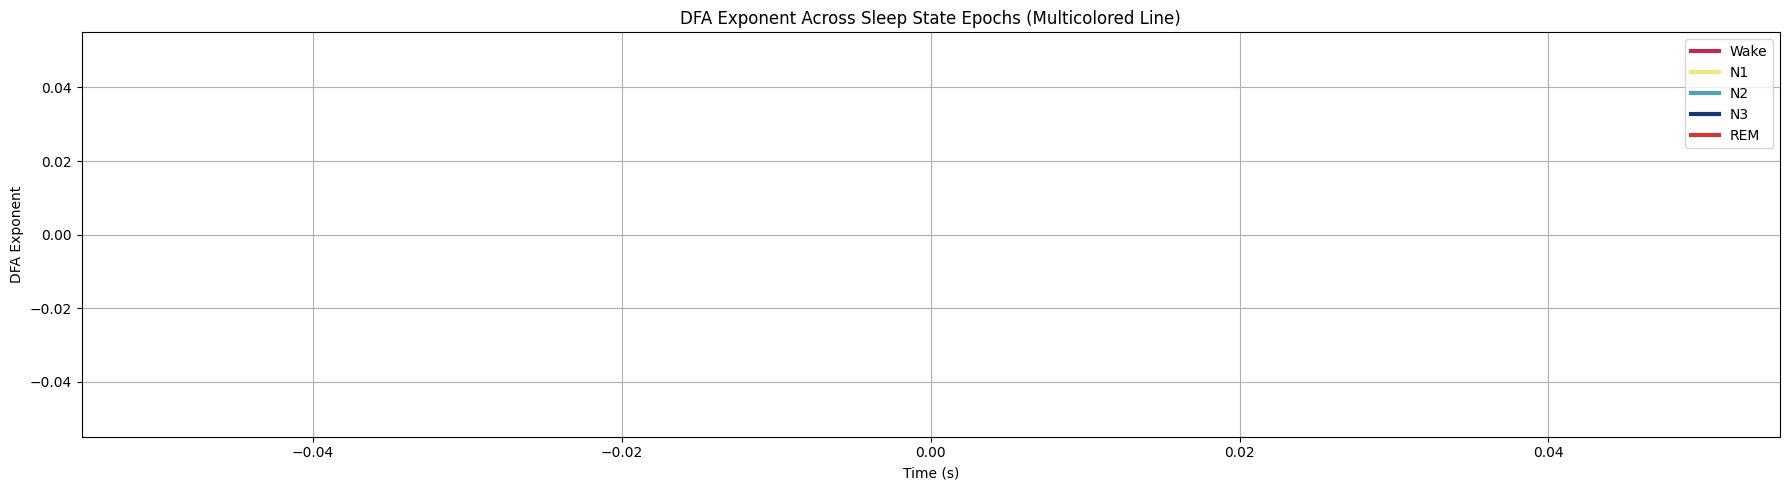

In [23]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

dfa_smoothed_exponents = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

In [24]:
# Create the Multiscale Entropy object
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

# Get the sleep stage-defined epochs
epochs = find_all_state_epochs(sleep_states)

mse_values_epoch = []
epoch_times_mse = []
epoch_labels_mse = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # include the end

    segment = lfp_PFC[start_sample:end_sample]

    # Skip very short segments (e.g., <2*Scale)
    #if len(segment) < fs * 2:
    #   continue

    try:
        MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')
        mse_values_epoch.append(np.mean(MSx))
        epoch_times_mse.append((start_sample + end_sample) / 2 / fs)
        epoch_labels_mse.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

 .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

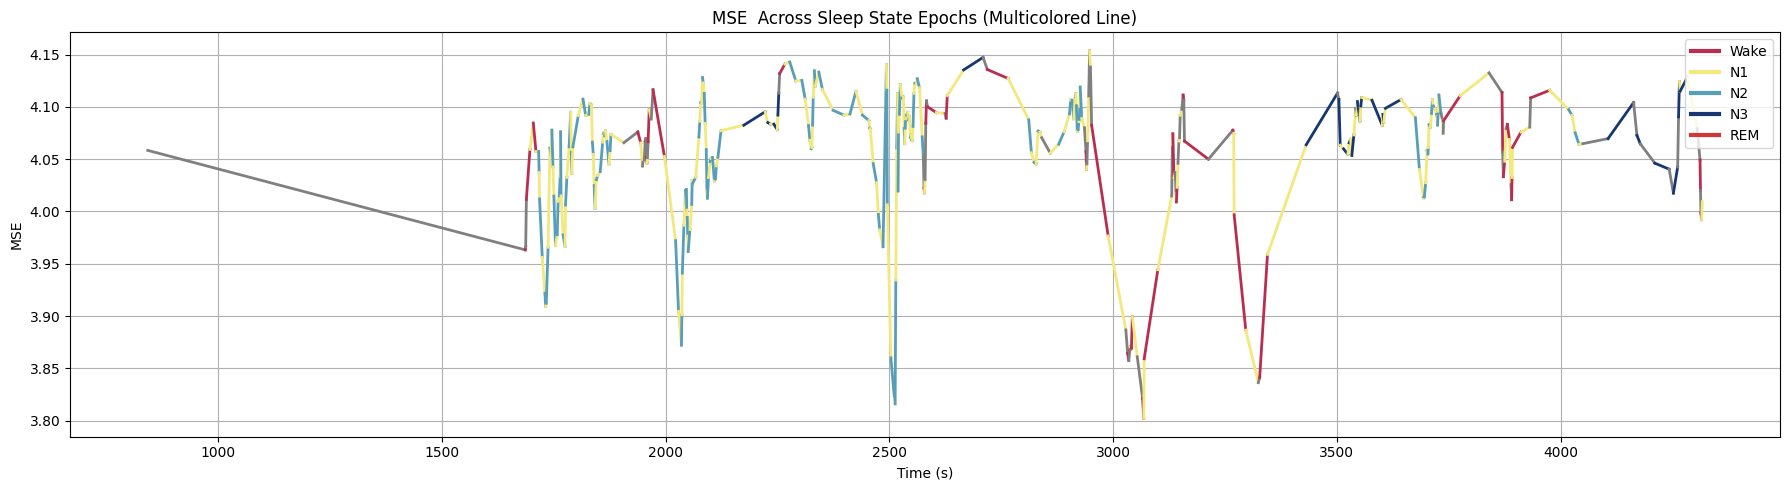

In [25]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(mse_values_epoch) >= 11 else len(mse_values_epoch) | 1  # ensure it's odd
polyorder = 4

mse_smoothed_exponents = savgol_filter(mse_values_epoch, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE  Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

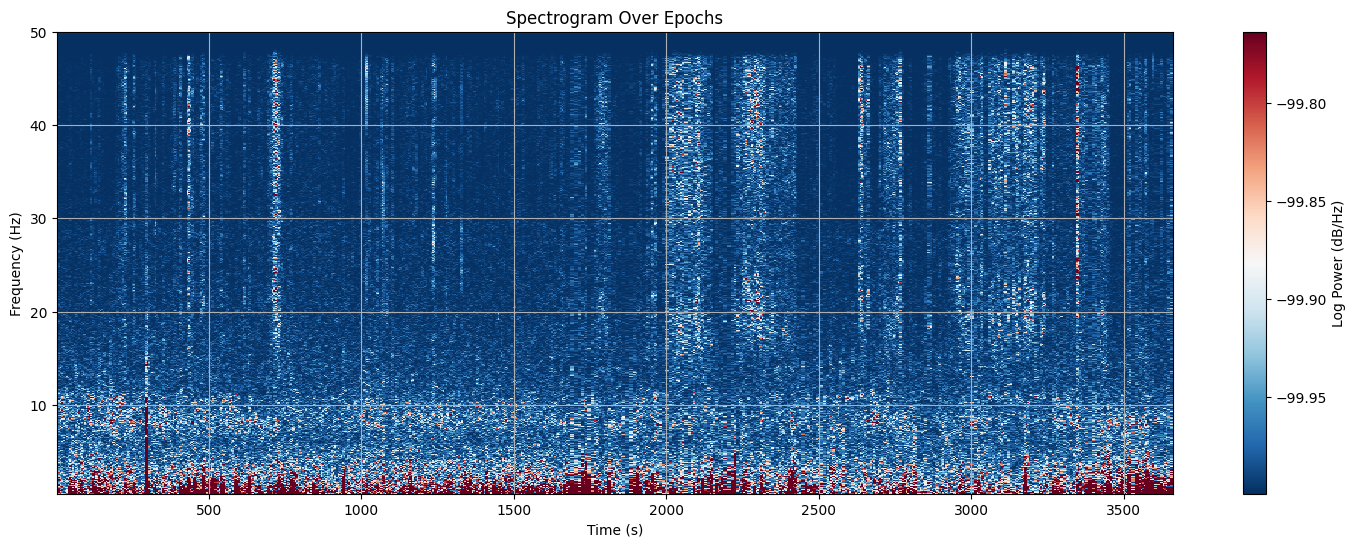

In [26]:
from scipy.signal import spectrogram

fmin, fmax = 0.5, 50
nperseg = int(10 * fs)
noverlap = nperseg // 2

# Get epochs
epochs = find_all_state_epochs(sleep_states)

# Init for concatenating results
spec_data = []
spec_times = []
spec_freqs = None
spec_colors = []

time_cursor = 0  # tracks where to place each epoch’s spectrogram

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs
    segment = lfp_PFC[start_sample:end_sample]

    # Skip too short segments
    if len(segment) < nperseg:
        continue

    f, t, Sxx = spectrogram(segment, fs=fs, nperseg=nperseg, noverlap=noverlap)

    # Filter frequencies
    freq_mask = (f >= fmin) & (f <= fmax)
    Sxx = Sxx[freq_mask, :]
    f = f[freq_mask]

    if spec_freqs is None:
        spec_freqs = f

    # Time correction to place each epoch properly on x-axis
    corrected_t = t + time_cursor
    spec_times.append(corrected_t)
    spec_data.append(Sxx)
    spec_colors.append(state)

    time_cursor += (len(segment) / fs)

# Concatenate
spec_data = np.concatenate(spec_data, axis=1)
spec_times = np.concatenate(spec_times)

# Convert to dB scale
Sxx_dB = 10 * np.log10(spec_data + 1e-10)

# Plot
plt.figure(figsize=(18, 6))
im = plt.pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
plt.colorbar(label='Log Power (dB/Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(fmin, fmax)
plt.title('Spectrogram Over Epochs')
plt.grid()
plt.show()

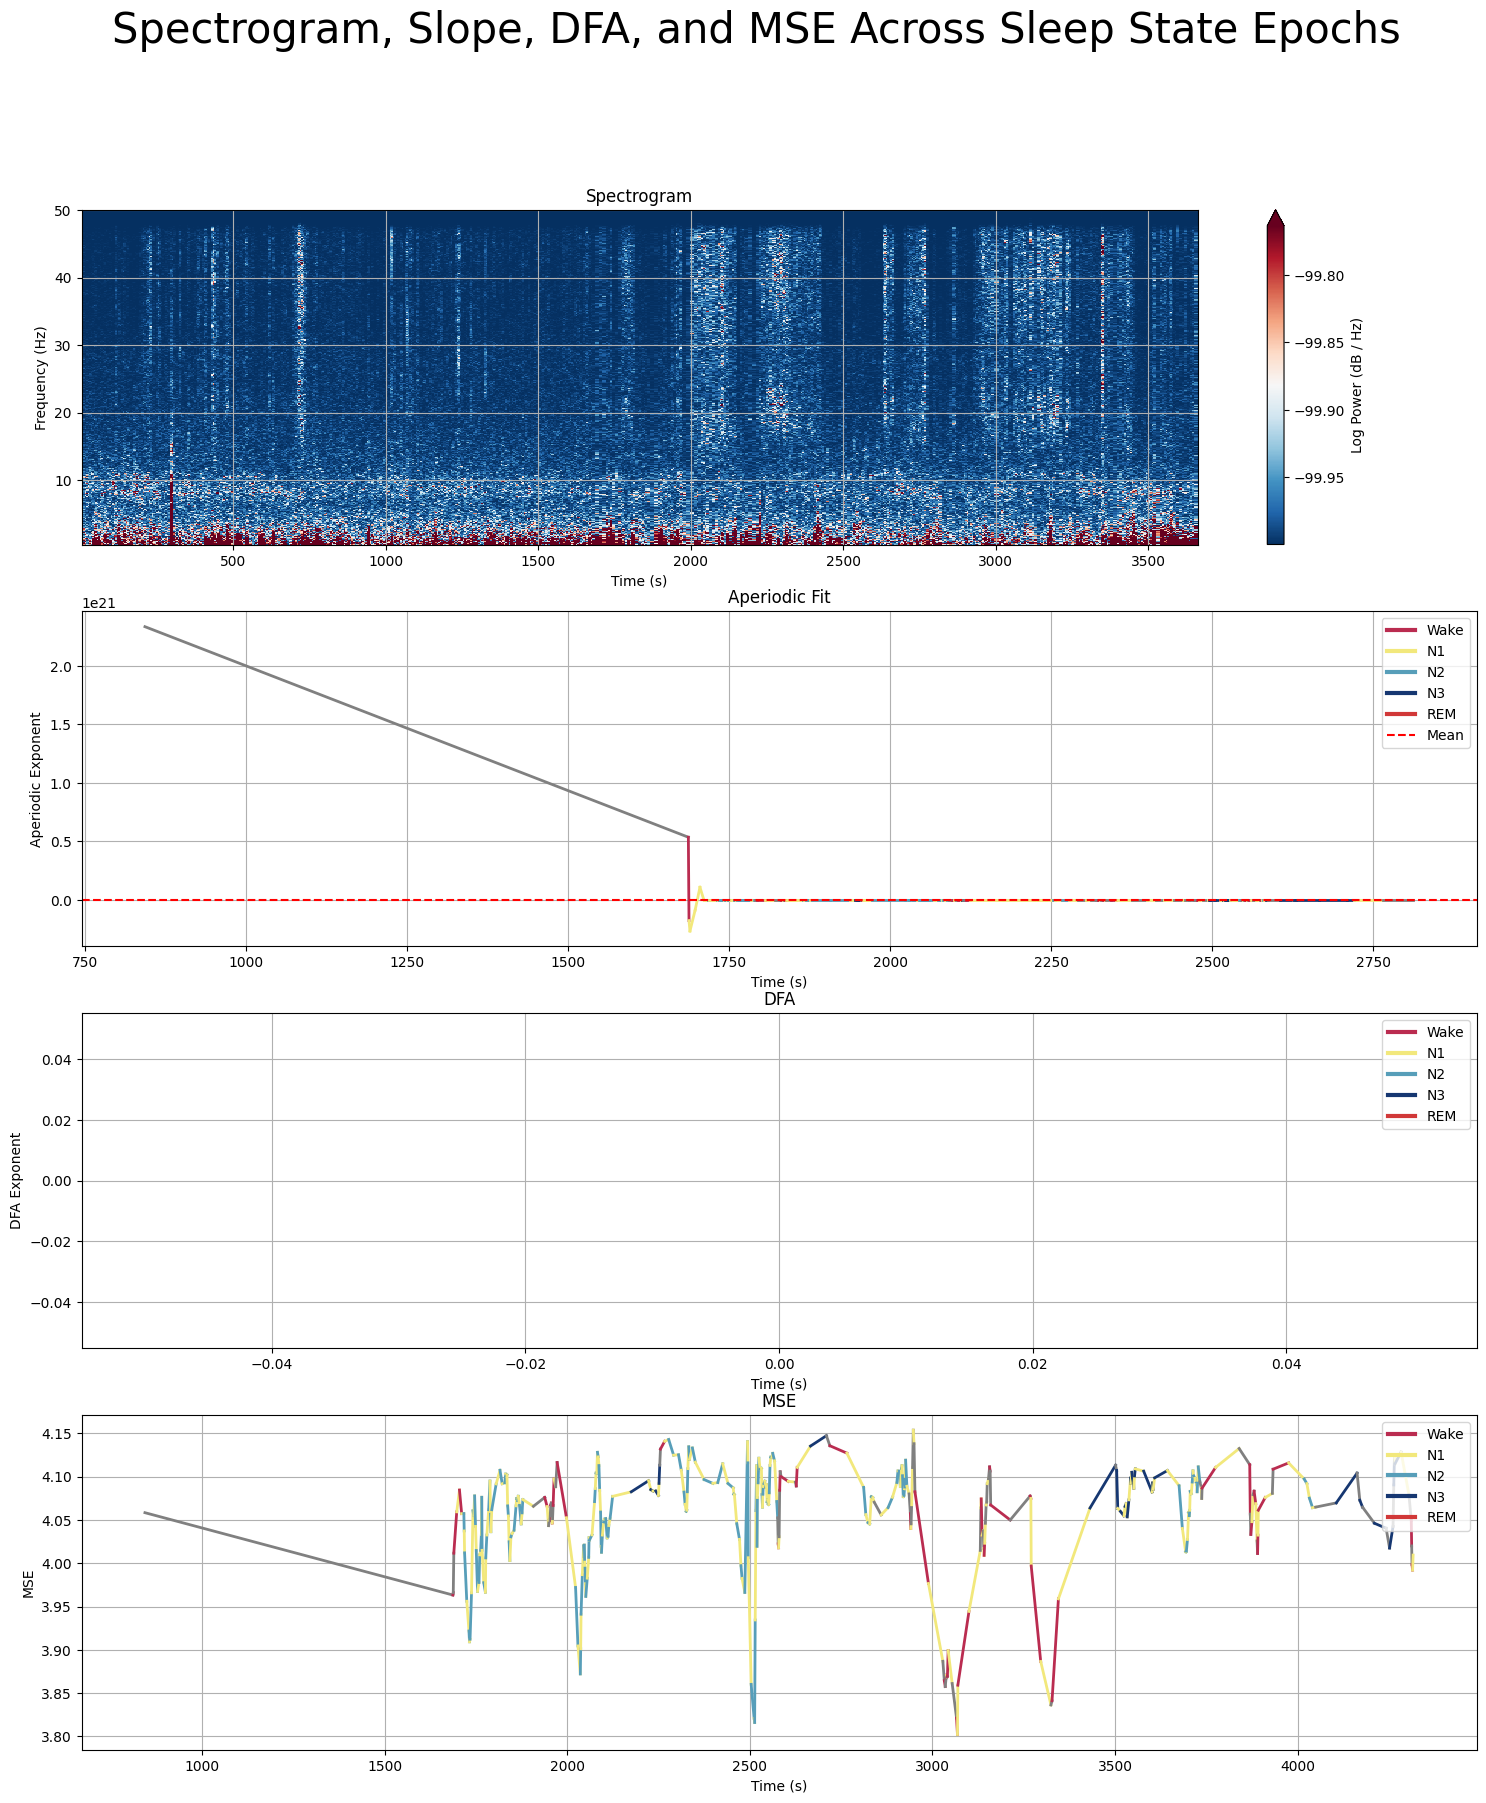

In [27]:
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE Across Sleep State Epochs', fontsize=30)

#SPECTROGRAM
im = axs[0].pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Frequency (Hz)')
axs[0].set_title('Spectrogram')
axs[0].grid()

# --- SLOPE ---
epoch_times_slope = epoch_times[:len(smoothed_exponents)]
for i in range(len(epoch_times_slope) - 1):
    x = [epoch_times_slope[i], epoch_times_slope[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    axs[1].plot(x, y, color=color, linewidth=2)

axs[1].axhline(0, color='red', linestyle='--', label='Mean')

axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Aperiodic Exponent')
axs[1].set_title('Aperiodic Fit')
axs[1].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
legend_elements.append(plt.Line2D([0], [0],  linestyle='--', color='red', label='Mean'))

axs[1].legend(handles=legend_elements, loc='upper right')

# --- DFA ---
epoch_times_dfa = epoch_times[:len(dfa_smoothed_exponents)]
for i in range(len(epoch_times_dfa) - 1):
    x = [epoch_times_dfa[i], epoch_times_dfa[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    axs[2].plot(x, y, color=color, linewidth=2)

axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA')
axs[2].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[2].legend(handles=legend_elements, loc='upper right')

# --- MSE ---
epoch_times_mse = epoch_times_mse[:len(mse_smoothed_exponents)]
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    axs[3].plot(x, y, color=color, linewidth=2)


axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE')
axs[3].grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[3].legend(handles=legend_elements, loc='upper right')
plt.savefig(f"{output_dir}/spec_slope_dfa_mse.svg", format='svg')
plt.show()

# OS Basic: Results for windowing (4s windows)

In [28]:
fs_osb = 250
window_size = 4 * fs_osb
step_size = window_size  # In case we wanted overlap later.

## Aperiodic Fit

In [29]:
num_windows = len(lfp_OSB) // window_size
time_stamps = np.arange(num_windows) * 4

aperiodic_exponents = []

for i in range(num_windows):
    start, end = i * window_size, (i + 1) * window_size
    window_data = lfp_OSB[start:end]

    freqs, psd = welch(window_data, fs=fs_osb, nperseg=1024)

    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]

    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
    fm.fit(freqs, psd)

    aperiodic_exponents.append(fm.get_params('aperiodic')[1])

aperiodic_exponents = np.array(aperiodic_exponents)

# Thresholding to remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]

#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(filtered_exponents) >= 11 else len(filtered_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - min(smoothed_exponents)) /(max(smoothed_exponents) - min(smoothed_exponents))) - 1

plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#plt.axhline(0, color='r', linestyle='--', label='Mean')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'lfp_OSB' is not defined

## DFA

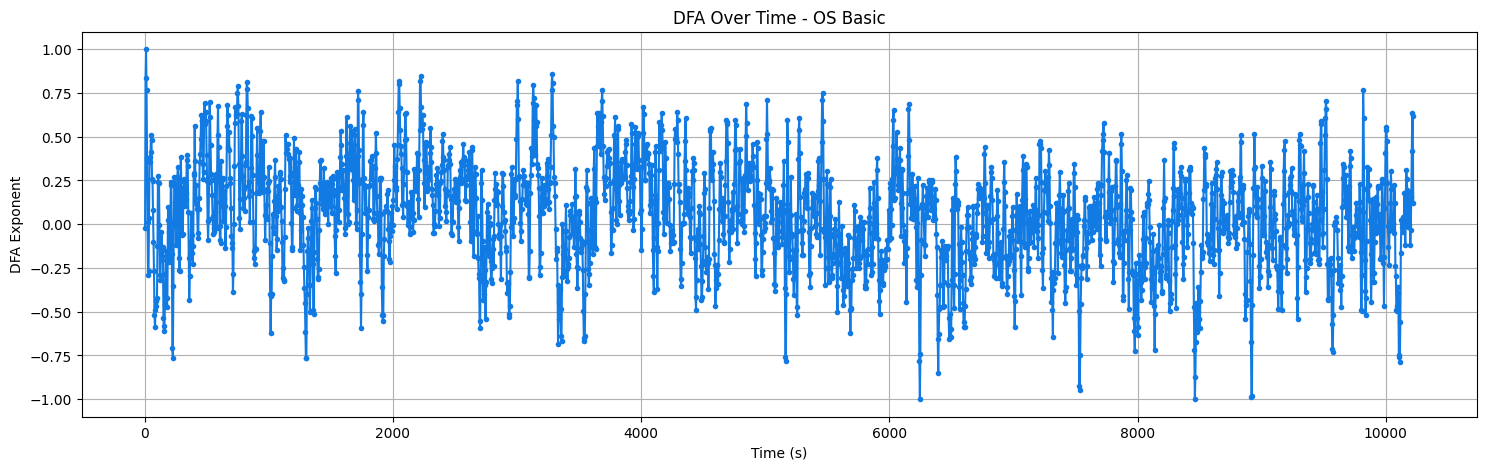

In [ ]:
num_windows = (len(lfp_OSB) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs_osb, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs_osb)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - OS Basic')
plt.grid()
plt.show()

## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

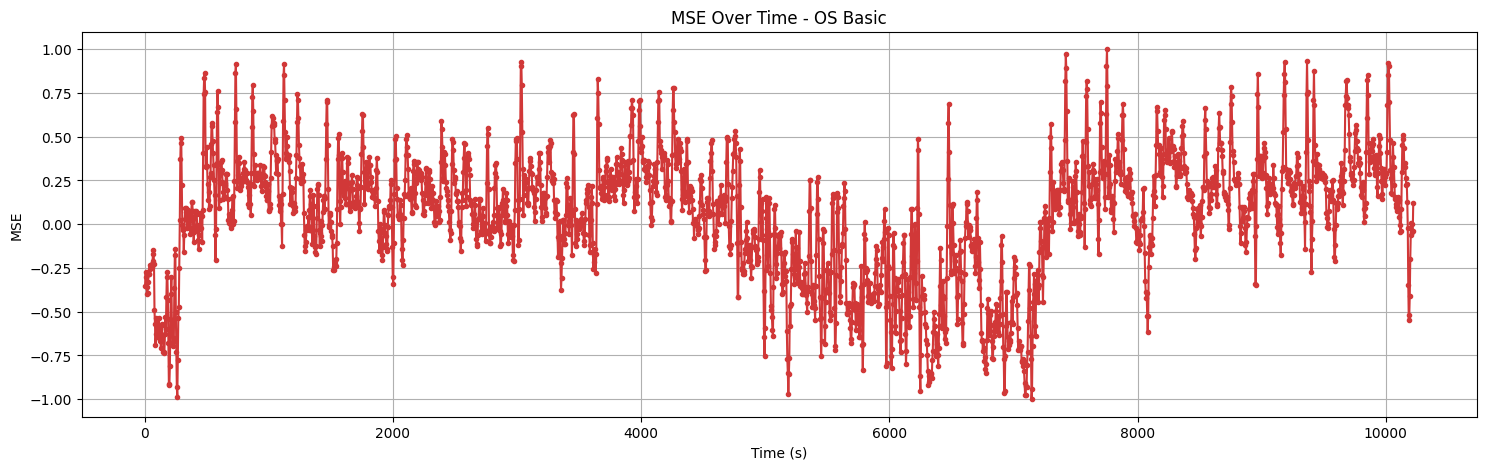

In [ ]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_OSB) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs_osb)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time - OS Basic')
plt.grid()
plt.show()

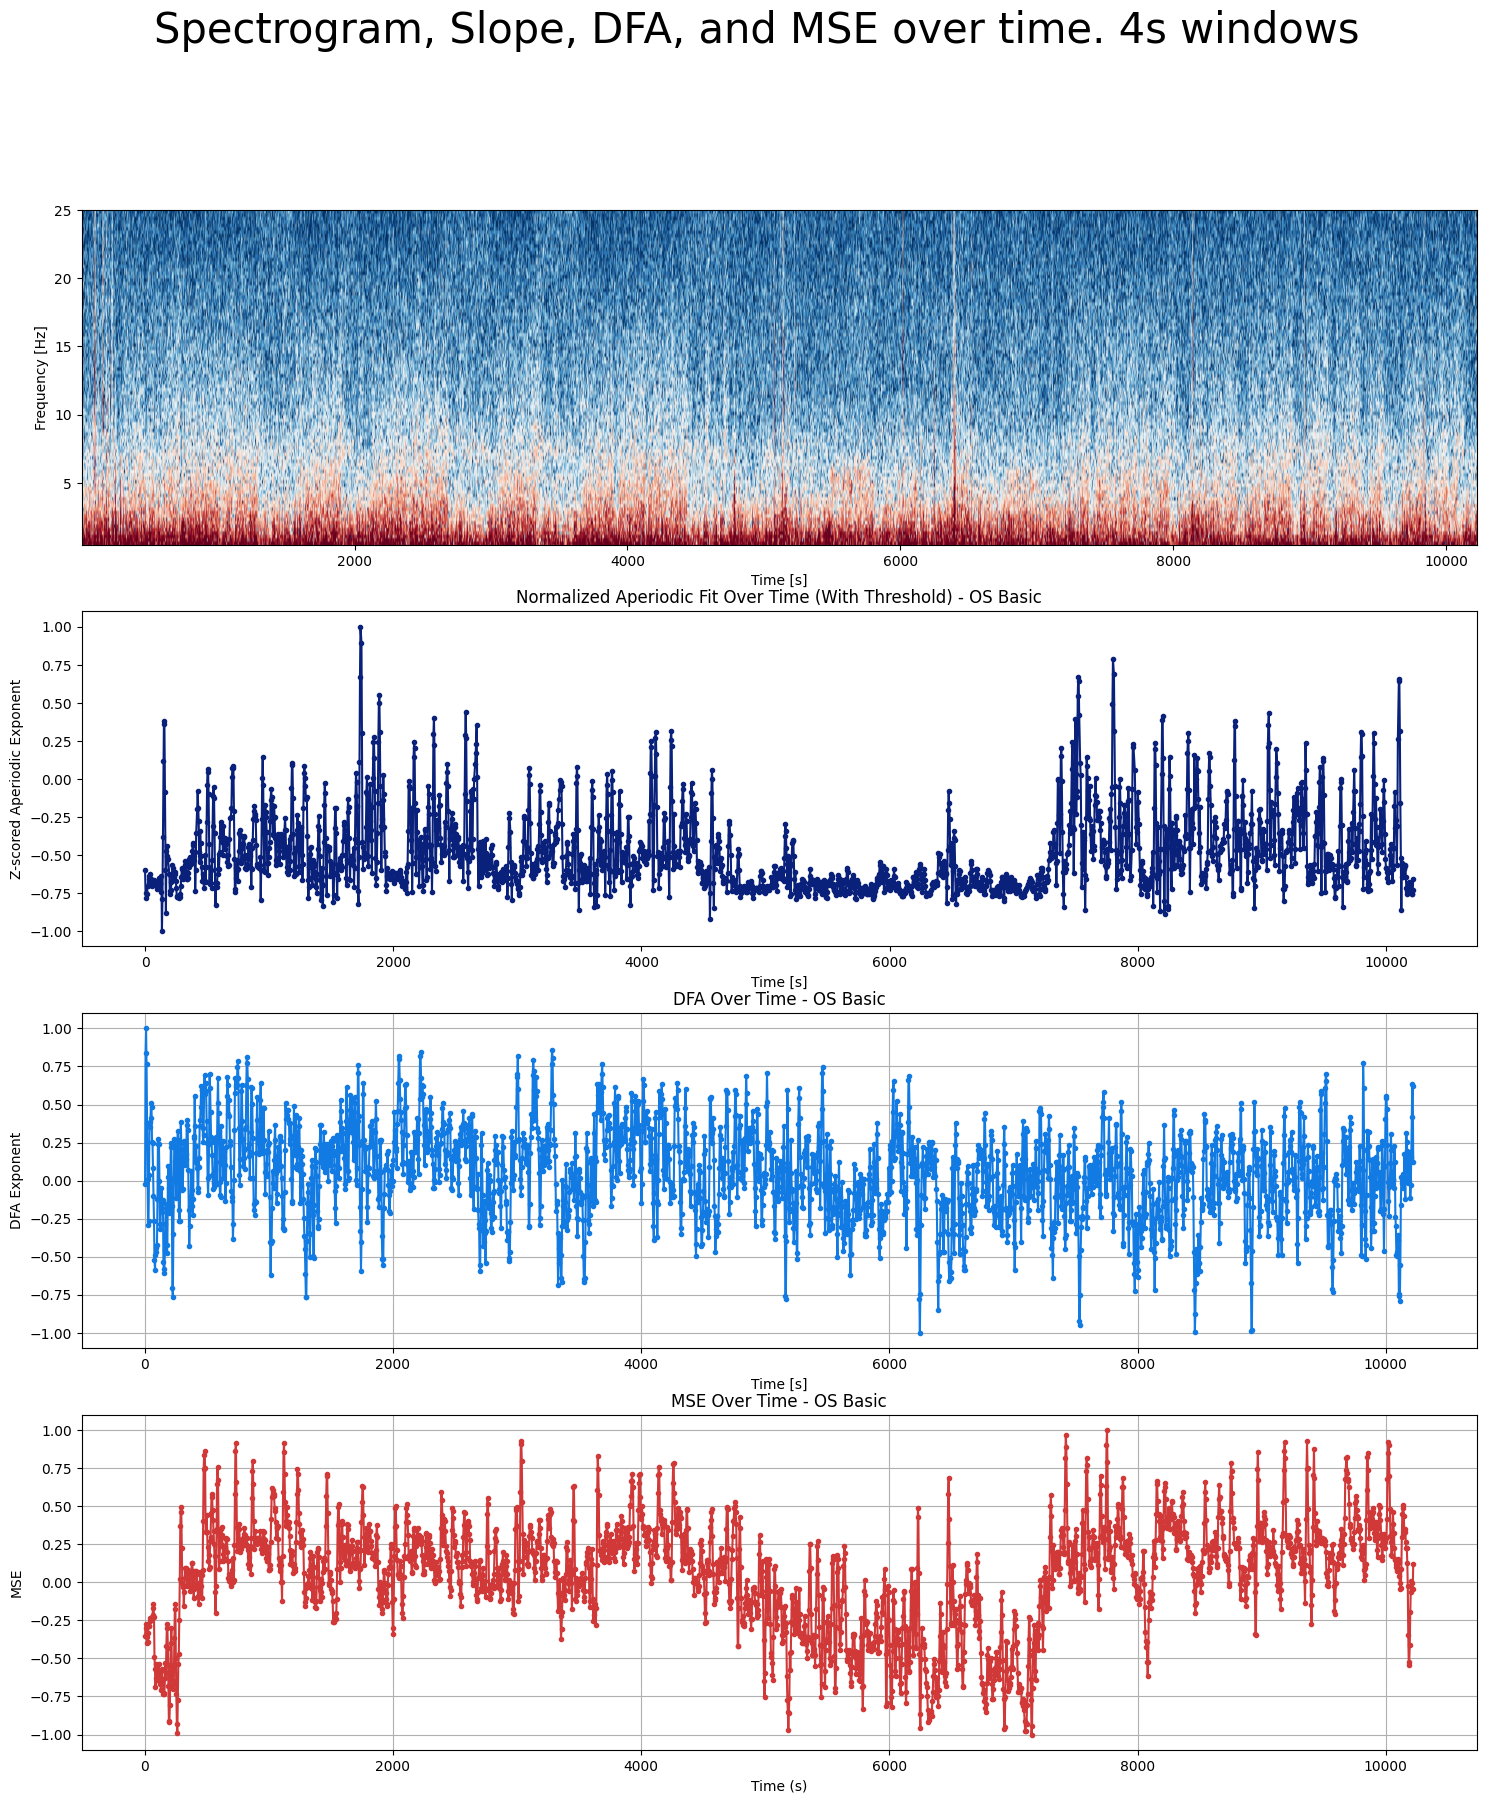

In [ ]:
# SPECTROGRAM
nperseg = int(4 * fs_osb)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - OS Basic', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_OSB, NFFT=nperseg, Fs=fs_osb, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
#cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time - OS Basic')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time - OS Basic')
axs[3].grid()

plt.show()